In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import warnings
warnings.filterwarnings("ignore")

print("✅ All libraries imported!")

✅ All libraries imported!


In [2]:
train_df = pd.read_csv("data/train_genetic_disorders.csv")  # ← update filename
test_df  = pd.read_csv("data/test_genetic_disorders.csv")   # ← update filename

print("Train shape:", train_df.shape)
print("Test shape: ", test_df.shape)
train_df.head()

Train shape: (22083, 45)
Test shape:  (9463, 43)


,Patient Id,Patient Age,Genes in mother's side,Inherited from father,Maternal gene,Paternal gene,Blood cell count (mcL),Patient First Name,Family Name,Father's name,...,Birth defects,White Blood cell count (thousand per microliter),Blood test result,Symptom 1,Symptom 2,Symptom 3,Symptom 4,Symptom 5,Genetic Disorder,Disorder Subclass
0,PID0x6418,2.0,Yes,No,Yes,No,4.760603,Richard,NaN,Larre,...,NaN,9.857562,NaN,1.0,1.0,1.0,1.0,1.0,Mitochondrial genetic inheritance disorders,Leber's hereditary optic neuropathy
1,PID0x25d5,4.0,Yes,Yes,No,No,4.910669,Mike,NaN,Brycen,...,Multiple,5.522560,normal,1.0,NaN,1.0,1.0,0.0,NaN,Cystic fibrosis
2,PID0x4a82,6.0,Yes,No,No,No,4.893297,Kimberly,NaN,Nashon,...,Singular,NaN,normal,0.0,1.0,1.0,1.0,1.0,Multifactorial genetic inheritance disorders,Diabetes
3,PID0x4ac8,12.0,Yes,No,Yes,No,4.705280,Jeffery,Hoelscher,Aayaan,...,Singular,7.919321,inconclusive,0.0,0.0,1.0,0.0,0.0,Mitochondrial genetic inheritance disorders,Leigh syndrome
4,PID0x1bf7,11.0,Yes,No,NaN,Yes,4.720703,Johanna,Stutzman,Suave,...,Multiple,4.098210,NaN,0.0,0.0,0.0,0.0,NaN,Multifactorial genetic inheritance disorders,Cancer


In [3]:
print("📊 Column Names:")
print(list(train_df.columns))

print("\n📊 Data Types:")
print(train_df.dtypes)

print("\n📊 Missing Values:")
print(train_df.isnull().sum())


📊 Column Names:
['Patient Id', 'Patient Age', "Genes in mother's side", 'Inherited from father', 'Maternal gene', 'Paternal gene', 'Blood cell count (mcL)', 'Patient First Name', 'Family Name', "Father's name", "Mother's age", "Father's age", 'Institute Name', 'Location of Institute', 'Status', 'Respiratory Rate (breaths/min)', 'Heart Rate (rates/min', 'Test 1', 'Test 2', 'Test 3', 'Test 4', 'Test 5', 'Parental consent', 'Follow-up', 'Gender', 'Birth asphyxia', 'Autopsy shows birth defect (if applicable)', 'Place of birth', 'Folic acid details (peri-conceptional)', 'H/O serious maternal illness', 'H/O radiation exposure (x-ray)', 'H/O substance abuse', 'Assisted conception IVF/ART', 'History of anomalies in previous pregnancies', 'No. of previous abortion', 'Birth defects', 'White Blood cell count (thousand per microliter)', 'Blood test result', 'Symptom 1', 'Symptom 2', 'Symptom 3', 'Symptom 4', 'Symptom 5', 'Genetic Disorder', 'Disorder Subclass']

📊 Data Types:
Patient Id           

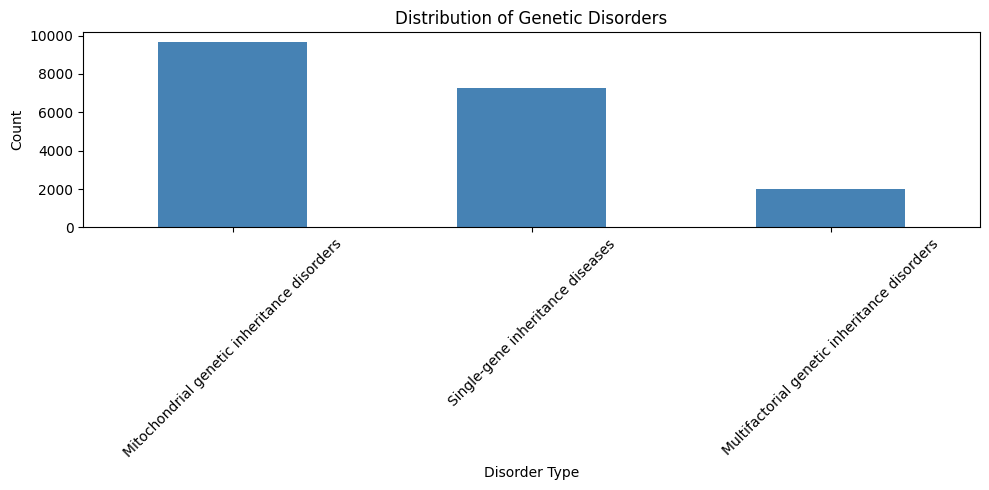

In [4]:
target = "Genetic Disorder"  # ← update if different

plt.figure(figsize=(10, 5))
train_df[target].value_counts().plot(kind="bar", color="steelblue")
plt.title("Distribution of Genetic Disorders")
plt.xlabel("Disorder Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [5]:
# Drop rows with too many missing values
# DO NOT drop rows - just fill missing values
df = train_df.copy()

# Drop target rows where label is missing
target = "Genetic Disorder"
df = df[df[target].notna()].reset_index(drop=True)

# Fill missing values column by column
for col in df.columns:
    if col == target:
        continue
    if df[col].dtype == "object":
        df[col] = df[col].fillna("Unknown")
    else:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        df[col] = df[col].fillna(df[col].median())

print("✅ Cleaning done!")
print("Shape:", df.shape)
print("Missing values left:", df.isnull().sum().sum())

✅ Cleaning done!
Shape: (18962, 45)
Missing values left: 0


In [6]:
le_dict = {}
df_encoded = df.copy()

for col in df_encoded.columns:
    if df_encoded[col].dtype == "object":
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
        le_dict[col] = le

print("✅ Encoding done!")
print("Shape:", df_encoded.shape)
df_encoded.head()

✅ Encoding done!
Shape: (18962, 45)


,Patient Id,Patient Age,Genes in mother's side,Inherited from father,Maternal gene,Paternal gene,Blood cell count (mcL),Patient First Name,Family Name,Father's name,...,Birth defects,White Blood cell count (thousand per microliter),Blood test result,Symptom 1,Symptom 2,Symptom 3,Symptom 4,Symptom 5,Genetic Disorder,Disorder Subclass
0,10397,2.0,1,0,2,0,4.760603,1895,5323,8504,...,2,9.857562,0,1.0,1.0,1.0,1.0,1.0,0,5
1,7146,6.0,1,0,0,0,4.893297,1277,5323,9944,...,1,7.465056,3,0.0,1.0,1.0,1.0,1.0,1,3
2,7170,12.0,1,0,2,0,4.705280,1089,2362,58,...,1,7.919321,2,0.0,0.0,1.0,0.0,0.0,0,6
3,1459,11.0,1,0,1,1,4.720703,1142,5064,12495,...,0,4.098210,0,0.0,0.0,0.0,0.0,0.0,1,1
4,6454,14.0,1,0,2,0,5.103188,1895,5323,2487,...,0,10.272230,3,1.0,0.0,0.0,1.0,0.0,2,2


In [7]:
X = df_encoded.drop(columns=[target])
y = df_encoded[target]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Unique disorders:", y.nunique())

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("\n✅ Model trained!")
print(f"📊 Validation Accuracy: {accuracy_score(y_val, model.predict(X_val)) * 100:.2f}%")

X shape: (18962, 44)
y shape: (18962,)
Unique disorders: 3

✅ Model trained!
📊 Validation Accuracy: 94.15%


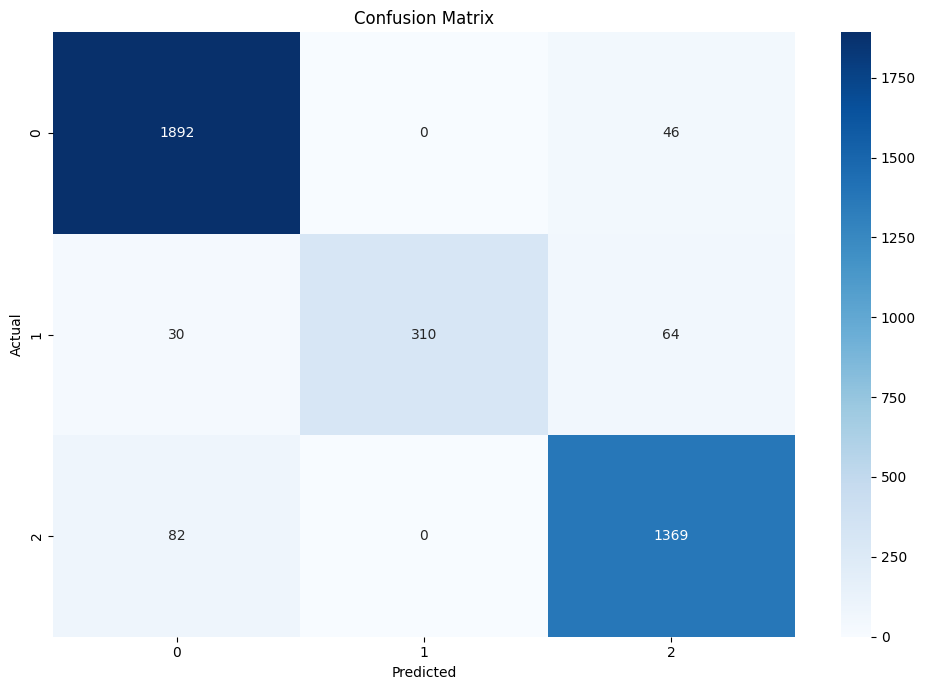

              precision    recall  f1-score   support

           0       0.94      0.98      0.96      1938
           1       1.00      0.77      0.87       404
           2       0.93      0.94      0.93      1451

    accuracy                           0.94      3793
   macro avg       0.96      0.90      0.92      3793
weighted avg       0.94      0.94      0.94      3793



In [8]:
preds = model.predict(X_val)

plt.figure(figsize=(10, 7))
cm = confusion_matrix(y_val, preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

print(classification_report(y_val, preds))

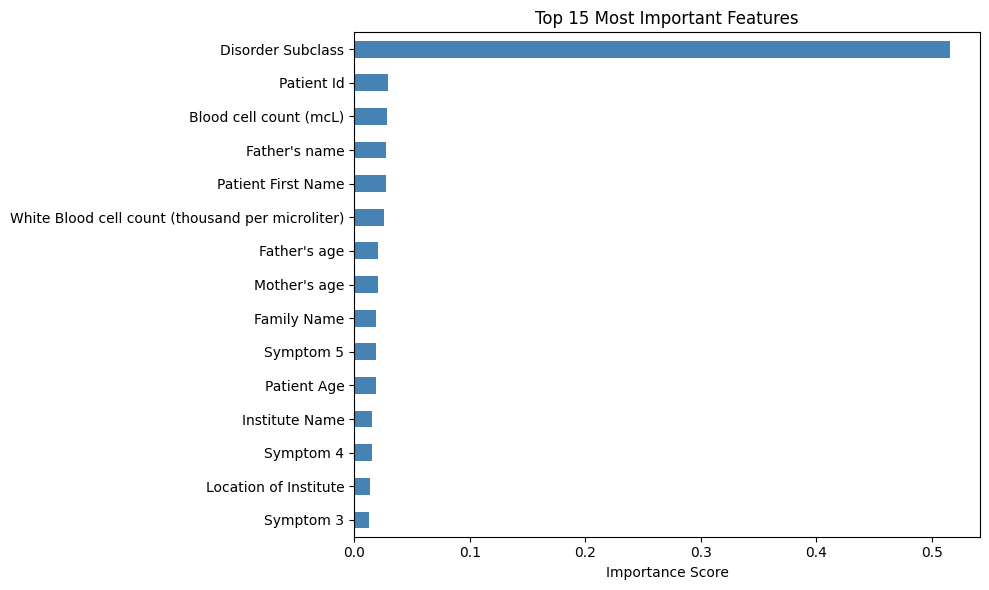

In [9]:
feat_importance = pd.Series(
    model.feature_importances_, index=X.columns
).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
feat_importance.plot(kind="barh", color="steelblue")
plt.title("Top 15 Most Important Features")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [10]:
import os
os.makedirs("models", exist_ok=True)

joblib.dump(model,            "models/disorder_model.pkl")
joblib.dump(list(X.columns), "models/feature_names.pkl")
joblib.dump(le_dict,         "models/label_encoders.pkl")

print("✅ Model saved successfully!")
print("📁 Files created:")
print("   - models/disorder_model.pkl")
print("   - models/feature_names.pkl")
print("   - models/label_encoders.pkl")

✅ Model saved successfully!
📁 Files created:
   - models/disorder_model.pkl
   - models/feature_names.pkl
   - models/label_encoders.pkl


In [11]:
# Cell 11 — Improve Model with Cross-Validation & Better Params
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

# Test with better hyperparameters
better_model = RandomForestClassifier(
    n_estimators=200,      # More trees = more stable
    max_depth=15,          # Prevents overfitting
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",  # Handles imbalanced classes
    random_state=42,
    n_jobs=-1              # Use all CPU cores
)

# Cross-validation (5-fold) — more reliable than single split
scores = cross_val_score(better_model, X, y, cv=5, scoring="accuracy")
print(f"Cross-validation scores: {scores}")
print(f"Mean accuracy: {scores.mean() * 100:.2f}%")
print(f"Std deviation: {scores.std() * 100:.2f}%")

# Train on full data and save
better_model.fit(X, y)
joblib.dump(better_model, "models/disorder_model.pkl")
print("\n✅ Improved model saved!")

Cross-validation scores: [0.93988927 0.94595307 0.94593882 0.94251055 0.94514768]
Mean accuracy: 94.39%
Std deviation: 0.24%

✅ Improved model saved!


In [14]:
from sklearn.metrics import classification_report
print(classification_report(y_val, model.predict(X_val)))

              precision    recall  f1-score   support

           0       0.94      0.98      0.96      1938
           1       1.00      0.77      0.87       404
           2       0.93      0.94      0.93      1451

    accuracy                           0.94      3793
   macro avg       0.96      0.90      0.92      3793
weighted avg       0.94      0.94      0.94      3793

